In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

FILE_PATH = r"D:\Python_For_DataScience\Stat\assignment\nepal_student_performance.csv"
df = pd.read_csv(FILE_PATH)
print("Shape:", df.shape)

Shape: (1200, 11)


Pearson r   : 0.0187
Spearman rho: 0.0801
Difference  : 0.0614


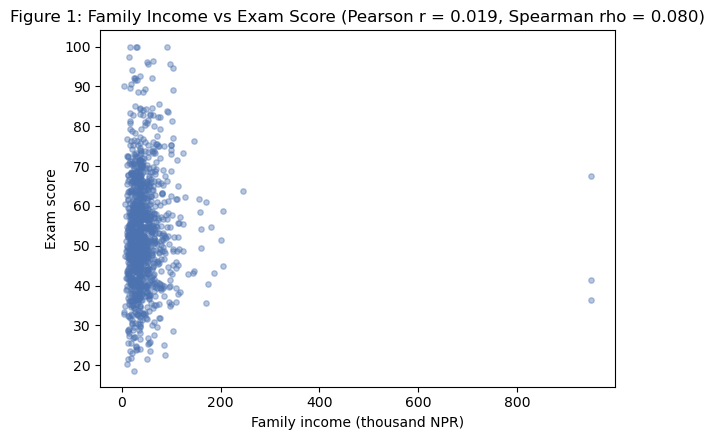

In [2]:
x = df["family_income"]
y = df["exam_score"]

pearson_r = x.corr(y, method="pearson")
spearman_rho = x.corr(y, method="spearman")

print("Pearson r   :", round(pearson_r, 4))
print("Spearman rho:", round(spearman_rho, 4))
print("Difference  :", round(abs(pearson_r - spearman_rho), 4))

plt.figure(figsize=(6, 4.5))
plt.scatter(x, y, alpha=0.4, s=15, color="#4C72B0")
plt.title(f"Figure 1: Family Income vs Exam Score (Pearson r = {pearson_r:.3f}, Spearman rho = {spearman_rho:.3f})")
plt.xlabel("Family income (thousand NPR)")
plt.ylabel("Exam score")
plt.tight_layout()
plt.show()

n (Yes): 636 | n (No): 564
Variance (Yes): 2223.9 | Variance (No): 3325.8
Independent t-test : TtestResult(statistic=np.float64(5.287659763813746), pvalue=np.float64(1.471442353355704e-07), df=np.float64(1198.0))
Welch's t-test     : TtestResult(statistic=np.float64(5.224987220850568), pvalue=np.float64(2.086154330048749e-07), df=np.float64(1089.1243978773607))
Mann-Whitney U     : MannwhitneyuResult(statistic=np.float64(253362.0), pvalue=np.float64(4.2451107383910394e-35))


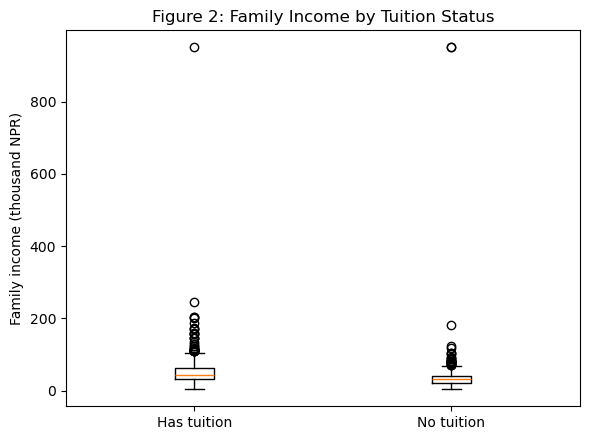

In [3]:
g1 = df.loc[df["has_tuition"] == "Yes", "family_income"].dropna()
g2 = df.loc[df["has_tuition"] == "No", "family_income"].dropna()

print("n (Yes):", len(g1), "| n (No):", len(g2))
print("Variance (Yes):", round(g1.var(), 1), "| Variance (No):", round(g2.var(), 1))

t_eq = stats.ttest_ind(g1, g2, equal_var=True)
t_welch = stats.ttest_ind(g1, g2, equal_var=False)
u_test = stats.mannwhitneyu(g1, g2)

print("Independent t-test :", t_eq)
print("Welch's t-test     :", t_welch)
print("Mann-Whitney U     :", u_test)

plt.figure(figsize=(6, 4.5))
plt.boxplot([g1, g2], tick_labels=["Has tuition", "No tuition"])
plt.title("Figure 2: Family Income by Tuition Status")
plt.ylabel("Family income (thousand NPR)")
plt.tight_layout()
plt.show()

Shapiro-Wilk statistic: 0.9827
Shapiro-Wilk p-value  : 9.270426911416366e-11
Skewness              : 0.527
n                     : 1200


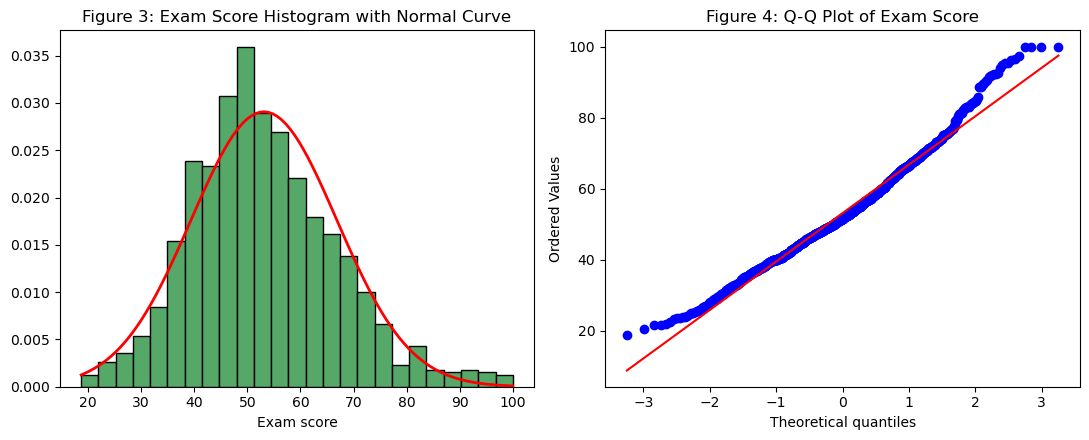

In [ ]:
sw_stat, sw_p = stats.shapiro(df["exam_score"])
print("Shapiro-Wilk statistic:", round(sw_stat, 4))
print("Shapiro-Wilk p-value  :", sw_p)
print("Skewness              :", round(df["exam_score"].skew(), 3))
print("n                     :", len(df))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(df["exam_score"], bins=25, color="#55A868", edgecolor="black", density=True)
mu, sigma = df["exam_score"].mean(), df["exam_score"].std()
xs = np.linspace(df["exam_score"].min(), df["exam_score"].max(), 100)
axes[0].plot(xs, stats.norm.pdf(xs, mu, sigma), color="red", linewidth=2)
axes[0].set_title("Figure 3: Exam Score Histogram with Normal Curve")
axes[0].set_xlabel("Exam score")

stats.probplot(df["exam_score"], dist="norm", plot=axes[1])
axes[1].set_title("Figure 4: Q-Q Plot of Exam Score")

plt.tight_layout()
plt.show()